**Step 1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
sns.set_style("whitegrid")

**Step 2: Load Dataset**

In [2]:
df = pd.read_csv('/content/StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Step 3: Understand Dataset Structure**

In [3]:
df.shape
df.columns
df.info()
df.describe()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


**Step 4: Check Missing Values**

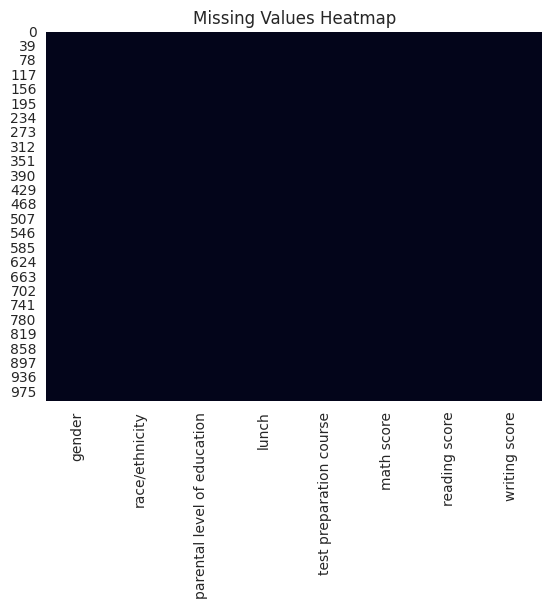

In [4]:
df.isnull().sum()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

**Step 5: Check Duplicate Records**

In [5]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

**Step 6: Explore Categorical Variables**

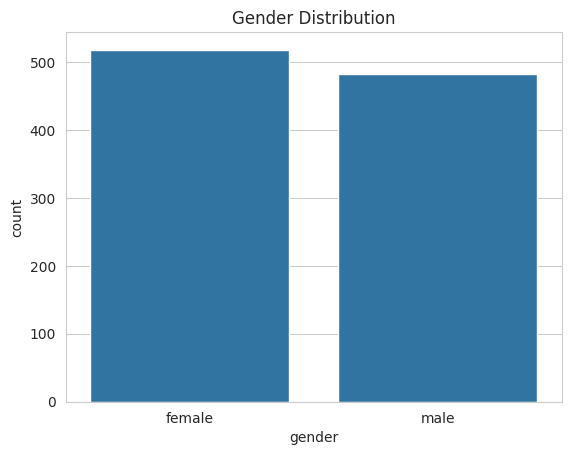

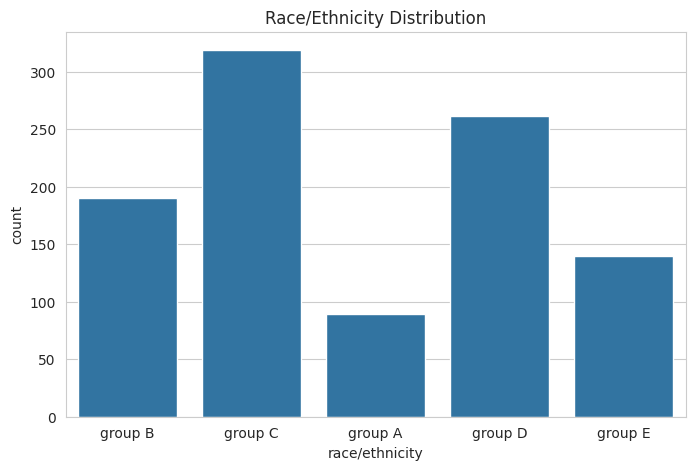

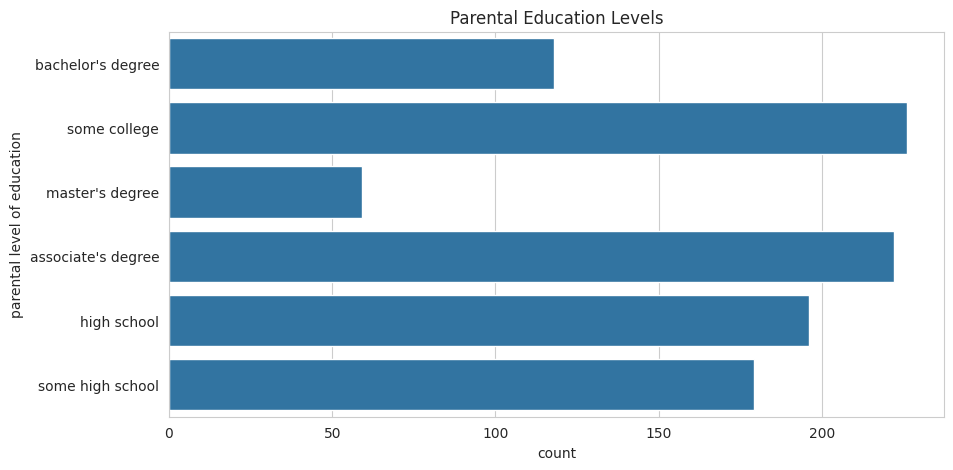

In [6]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()
plt.figure(figsize=(8,5))
sns.countplot(x='race/ethnicity', data=df)
plt.title("Race/Ethnicity Distribution")
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(y='parental level of education', data=df)
plt.title("Parental Education Levels")
plt.show()

**Step 7: Explore Numerical Variables**

**HISTOGRAM**

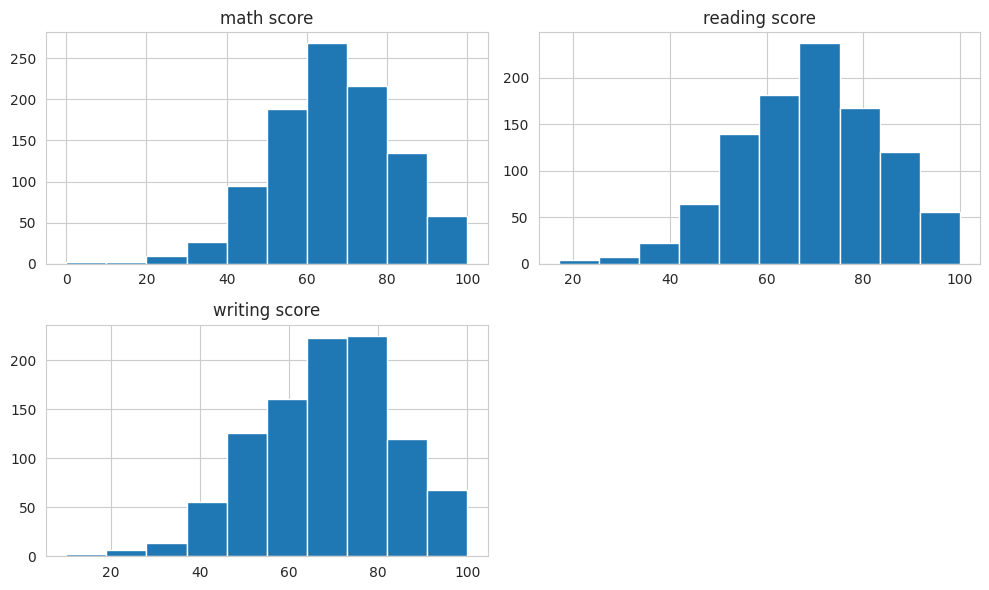

In [7]:
df.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

**DISTRIBUTION PLOTS**

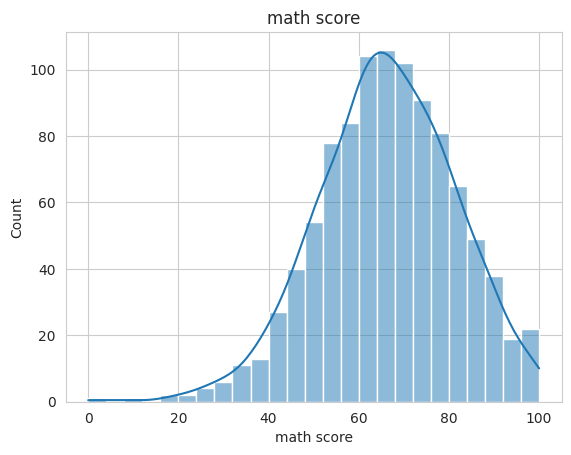

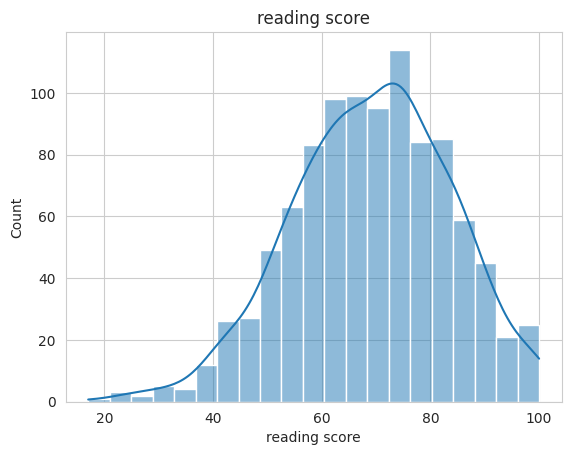

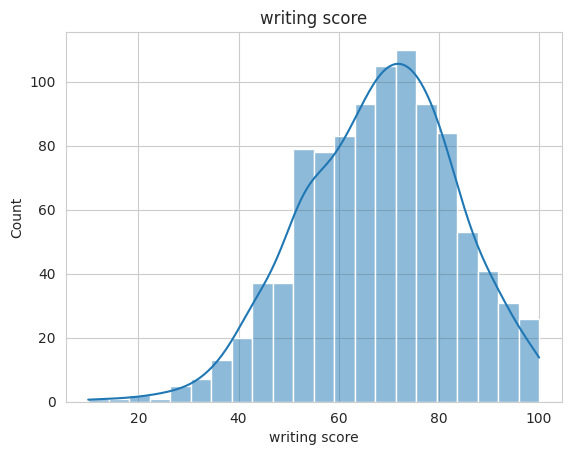

In [8]:
for col in ['math score','reading score','writing score']:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

**Step 8: Analyze Student Scores**

**Average Scores**

In [9]:
df[['math score','reading score','writing score']].mean()

,0
math score,66.089
reading score,69.169
writing score,68.054


**Maximum Scores**

In [10]:
df[['math score','reading score','writing score']].max()

,0
math score,100
reading score,100
writing score,100


**Minimum Scores**

In [11]:
df[['math score','reading score','writing score']].min()

,0
math score,0
reading score,17
writing score,10


**Step 9: Create Total and Average Score**

In [12]:
df['Total Score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

df['Average Score'] = df['Total Score'] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


**Step 10: Performance Distribution**

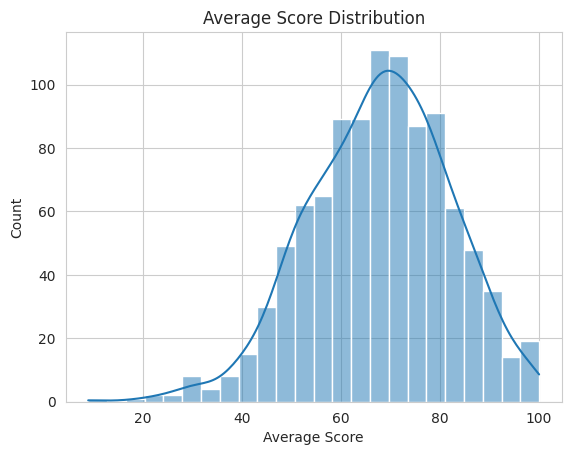

In [13]:
sns.histplot(df['Average Score'], kde=True)
plt.title("Average Score Distribution")
plt.show()

**Step 11: Gender vs Scores**

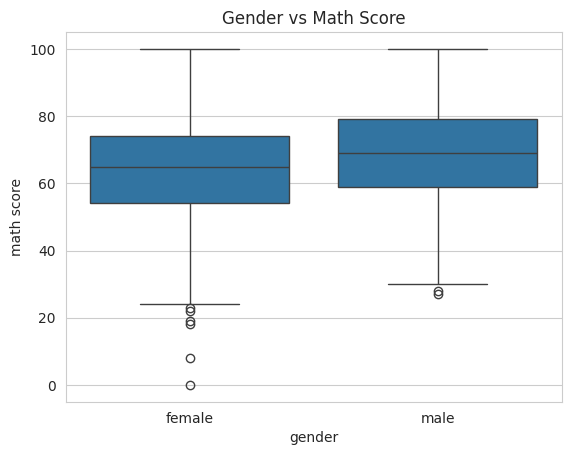

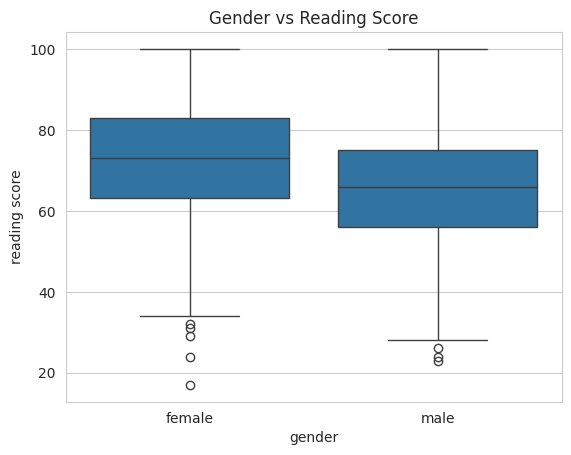

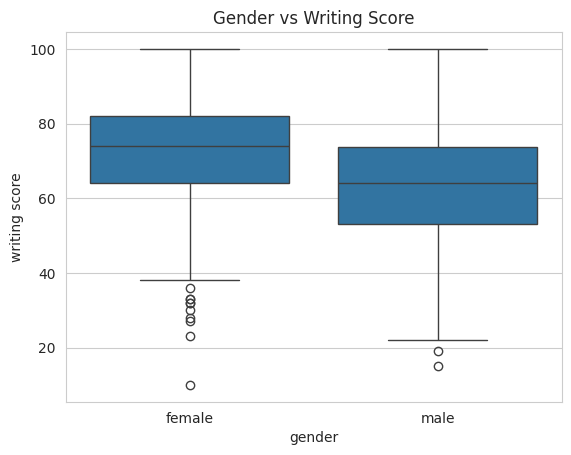

In [14]:
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Gender vs Math Score")
plt.show()
sns.boxplot(x='gender', y='reading score', data=df)
plt.title("Gender vs Reading Score")
plt.show()
sns.boxplot(x='gender', y='writing score', data=df)
plt.title("Gender vs Writing Score")
plt.show()

**Step 12: Lunch Type Impact**

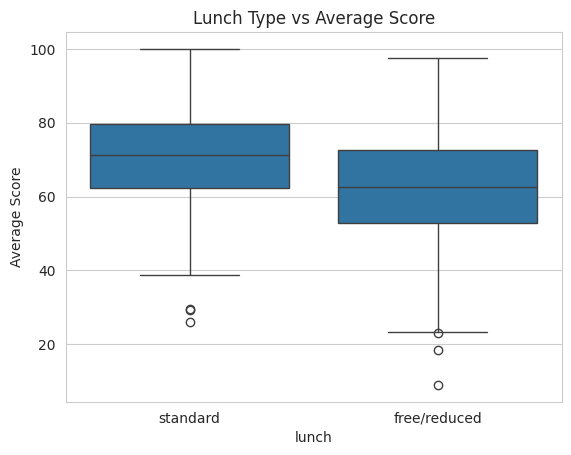

In [15]:
sns.boxplot(
    x='lunch',
    y='Average Score',
    data=df
)
plt.title("Lunch Type vs Average Score")
plt.show()

**Step 13: Test Preparation Impact**

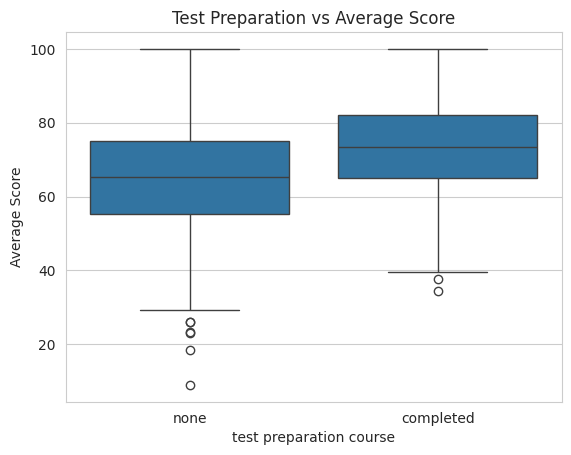

In [16]:
sns.boxplot(
    x='test preparation course',
    y='Average Score',
    data=df
)
plt.title("Test Preparation vs Average Score")
plt.show()

**Step 14: Parent Education Impact**

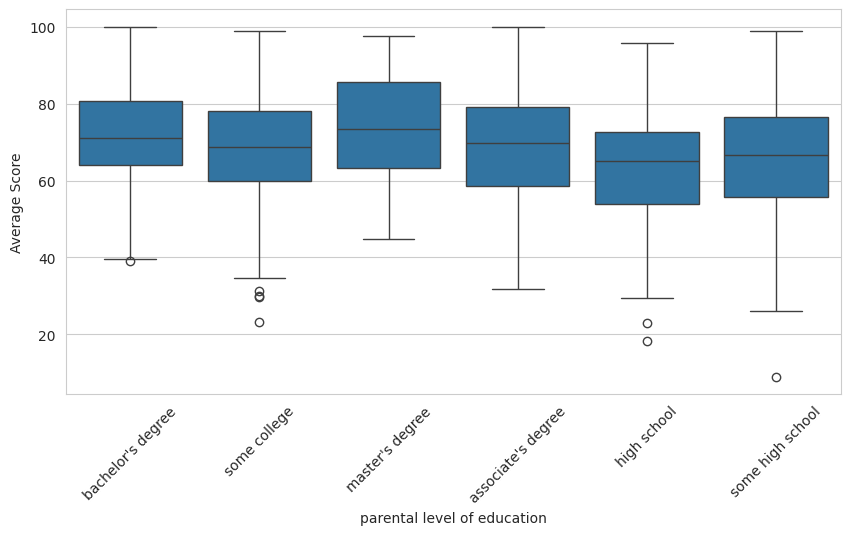

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='parental level of education',
    y='Average Score',
    data=df
)

plt.xticks(rotation=45)
plt.show()

**Step 15: Correlation Analysis**

In [18]:
corr = df[['math score',
           'reading score',
           'writing score',
           'Average Score']].corr()

corr

,math score,reading score,writing score,Average Score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
Average Score,0.918746,0.970331,0.965667,1.000000


**Correlation Heatmap**

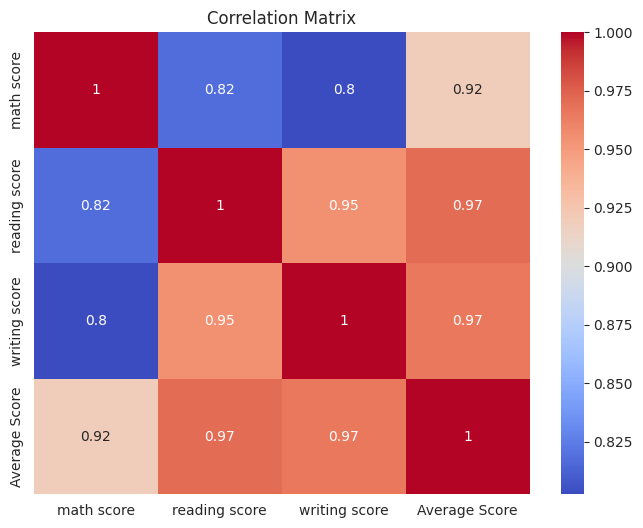

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

**Step 16: Relationship Between Scores**

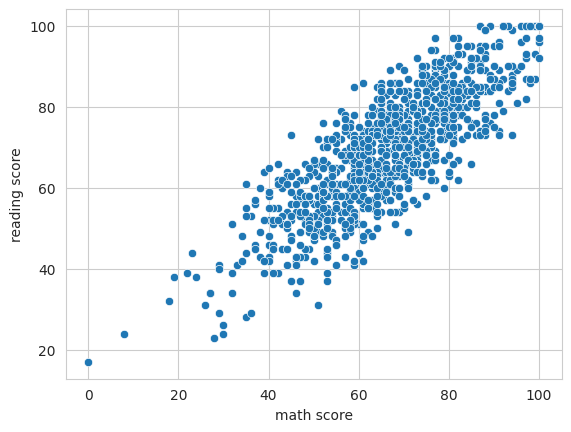

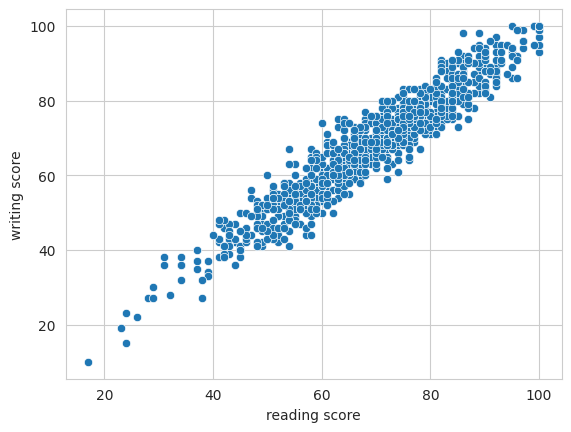

In [20]:
sns.scatterplot(
    x='math score',
    y='reading score',
    data=df
)
plt.show()
sns.scatterplot(
    x='reading score',
    y='writing score',
    data=df
)
plt.show()

**Step 17: Top Performing Students**

In [21]:
top_students = df.sort_values(
    by='Average Score',
    ascending=False
)

top_students.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,300,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,300,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,299,99.666667
712,female,group D,some college,standard,none,98,100,99,297,99.000000
179,female,group D,some high school,standard,completed,97,100,100,297,99.000000
165,female,group C,bachelor's degree,standard,completed,96,100,100,296,98.666667
625,male,group D,some college,standard,completed,100,97,99,296,98.666667
685,female,group E,master's degree,standard,completed,94,99,100,293,97.666667
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,293,97.666667


**Step 18: Identify Outliers**

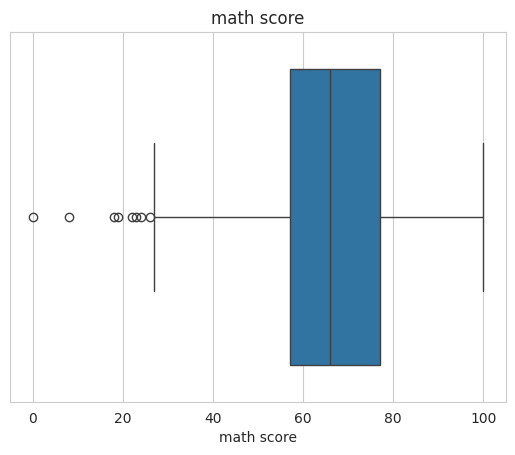

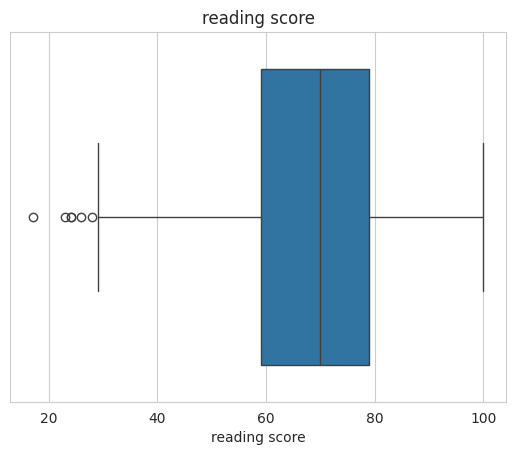

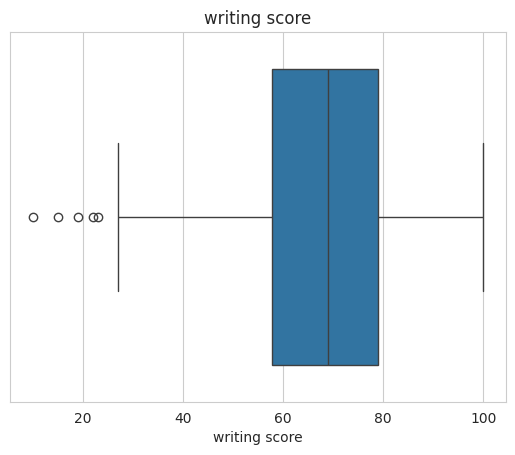

In [22]:
for col in ['math score',
            'reading score',
            'writing score']:

    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()